# Time Series Data

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.tsa.stattools as sts
import seaborn as sns
sns.set_style('darkgrid')

In [17]:
raw_data = pd.read_csv("data/Index2018.csv")
raw_data.head()

,date,spx,dax,ftse,nikkei
0,07/01/1994,469.90,2224.95,3445.98,18124.01
1,10/01/1994,475.27,2225.00,3440.58,18443.44
2,11/01/1994,474.13,2228.10,3413.77,18485.25
3,12/01/1994,474.17,2182.06,3372.02,18793.88
4,13/01/1994,472.47,2142.37,3360.01,18577.26


In [18]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6269 entries, 0 to 6268
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    6269 non-null   str    
 1   spx     6269 non-null   float64
 2   dax     6269 non-null   float64
 3   ftse    6269 non-null   float64
 4   nikkei  6269 non-null   float64
dtypes: float64(4), str(1)
memory usage: 306.2 KB


In [19]:
df_copy = raw_data.copy()

In [20]:
df_copy.head()

,date,spx,dax,ftse,nikkei
0,07/01/1994,469.90,2224.95,3445.98,18124.01
1,10/01/1994,475.27,2225.00,3440.58,18443.44
2,11/01/1994,474.13,2228.10,3413.77,18485.25
3,12/01/1994,474.17,2182.06,3372.02,18793.88
4,13/01/1994,472.47,2142.37,3360.01,18577.26


In [21]:
df_copy.describe().T

,count,mean,std,min,25%,50%,75%,max
spx,6269.0,1288.127542,487.586473,438.92,990.671905,1233.42,1459.987747,2872.867839
dax,6269.0,6080.063363,2754.361032,1911.70,4069.350000,5773.34,7443.070000,13559.600000
ftse,6269.0,5422.713545,1145.572428,2876.60,4486.100000,5662.43,6304.250000,7778.637689
nikkei,6269.0,14597.055700,4043.122953,7054.98,10709.290000,15028.17,17860.470000,24124.150000


In [22]:
df_copy.isnull().sum()  

date      0
spx       0
dax       0
ftse      0
nikkei    0
dtype: int64

In [25]:
# convert date to datetime
df_copy['date'] = pd.to_datetime(df_copy['date'], format='%d/%m/%Y')
df_copy = df_copy.set_index('date')
df_copy.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 6269 entries, 1994-01-07 to 2018-01-29
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   spx     6269 non-null   float64
 1   dax     6269 non-null   float64
 2   ftse    6269 non-null   float64
 3   nikkei  6269 non-null   float64
dtypes: float64(4)
memory usage: 244.9 KB


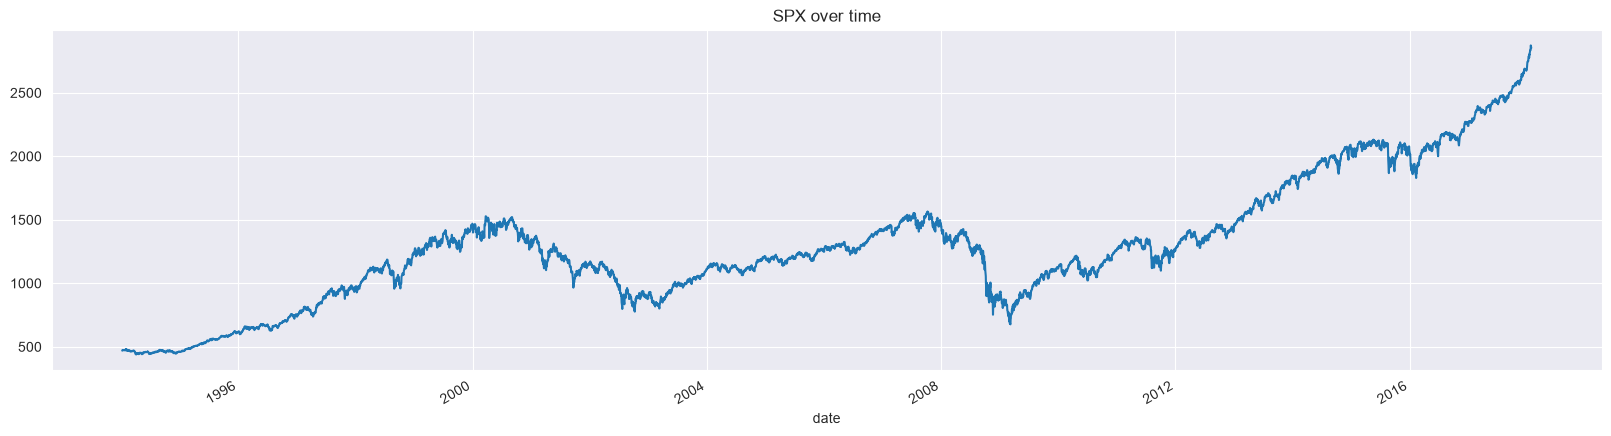

In [26]:
df_copy.spx.plot(title="SPX over time", figsize=(20, 5))
plt.show()

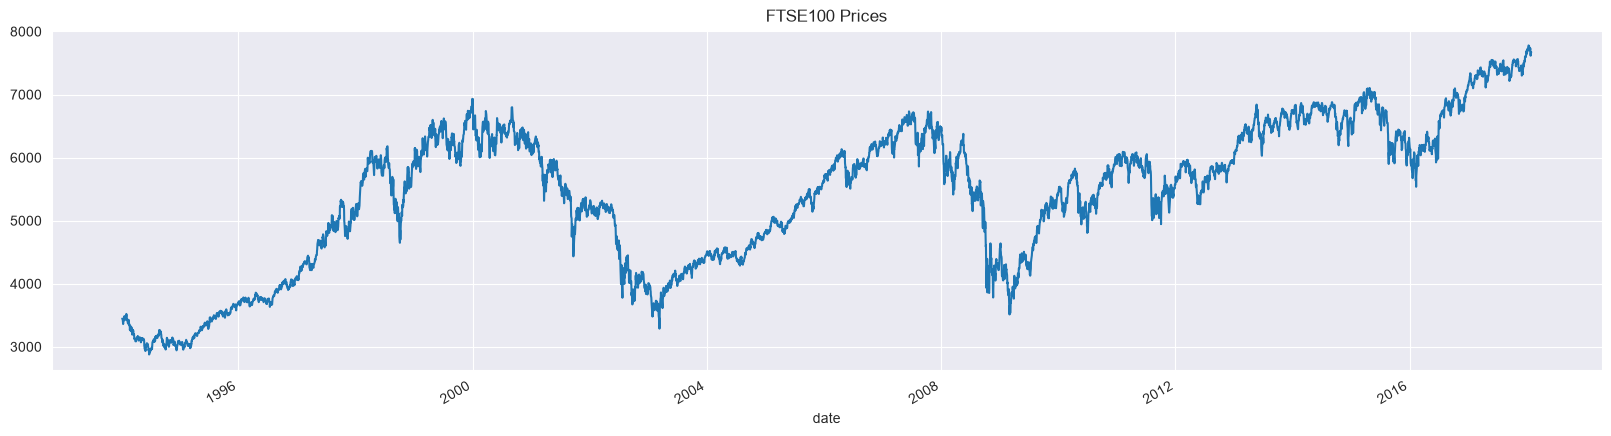

In [27]:
df_copy.ftse.plot(title="FTSE100 Prices", figsize=(20, 5))
plt.show()

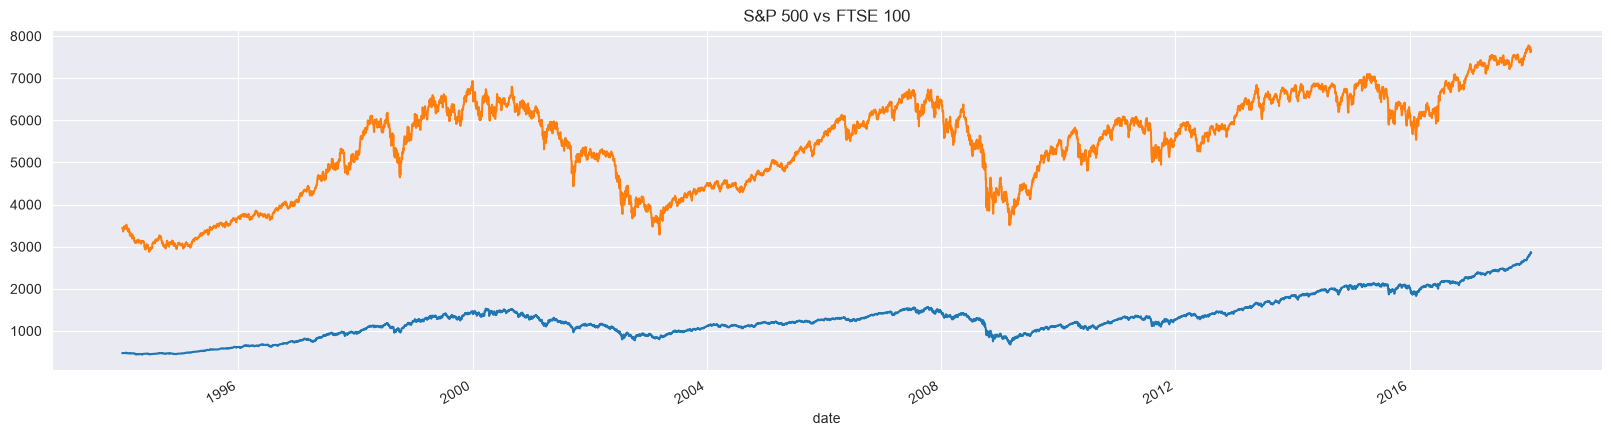

In [28]:
df_copy.spx.plot(figsize=(20,5), title="S&P 500 Prices")
df_copy.ftse.plot(figsize=(20,5), title="FTSE 100 Prices")
plt.title("S&P 500 vs FTSE 100")
plt.show()

## Setting the Frequency

In [30]:
df_copy = df_copy.asfreq("D")

In [31]:
df_copy.head()

,spx,dax,ftse,nikkei
date,,,,
1994-01-07,469.90,2224.95,3445.98,18124.01
1994-01-08,NaN,NaN,NaN,NaN
1994-01-09,NaN,NaN,NaN,NaN
1994-01-10,475.27,2225.00,3440.58,18443.44
1994-01-11,474.13,2228.10,3413.77,18485.25


In [33]:
df_copy = df_copy.asfreq("B")

In [34]:
df_copy.head()

,spx,dax,ftse,nikkei
date,,,,
1994-01-07,469.90,2224.95,3445.98,18124.01
1994-01-10,475.27,2225.00,3440.58,18443.44
1994-01-11,474.13,2228.10,3413.77,18485.25
1994-01-12,474.17,2182.06,3372.02,18793.88
1994-01-13,472.47,2142.37,3360.01,18577.26


## Handling Missing Values

In [35]:
df_copy.isnull()

,spx,dax,ftse,nikkei
date,,,,
1994-01-07,False,False,False,False
1994-01-10,False,False,False,False
1994-01-11,False,False,False,False
1994-01-12,False,False,False,False
1994-01-13,False,False,False,False
...,...,...,...,...
2018-01-23,False,False,False,False
2018-01-24,False,False,False,False
2018-01-25,False,False,False,False


In [36]:
df_copy.isnull().sum()  

spx       8
dax       8
ftse      8
nikkei    8
dtype: int64

In [38]:
df_copy.spx = df_copy.spx.ffill()

In [39]:
df_copy.isnull().sum()

spx       0
dax       8
ftse      8
nikkei    8
dtype: int64

In [40]:
df_copy.ftse = df_copy.ftse.bfill()

In [41]:
df_copy.isnull().sum()

spx       0
dax       8
ftse      0
nikkei    8
dtype: int64

In [42]:
df_copy.dax = df_copy.dax.ffill().bfill()

In [43]:
df_copy.isnull().sum()

spx       0
dax       0
ftse      0
nikkei    8
dtype: int64

In [44]:
df_copy.nikkei = df_copy.nikkei.ffill()

In [45]:
df_copy.isnull().sum()

spx       0
dax       0
ftse      0
nikkei    0
dtype: int64

### Simplifying the dataset

In [46]:
df_copy['market_value'] = df_copy.spx

In [47]:
df_copy.describe().T    

,count,mean,std,min,25%,50%,75%,max
spx,6277.0,1288.642547,487.868210,438.92,992.715221,1233.761241,1460.250000,2872.867839
dax,6277.0,6083.381061,2755.563853,1911.70,4070.460000,5774.260000,7445.560000,13559.600000
ftse,6277.0,5423.690398,1145.568370,2876.60,4487.880000,5663.300000,6304.630175,7778.637689
nikkei,6277.0,14597.672753,4043.795272,7054.98,10701.130000,15030.510000,17860.470000,24124.150000
market_value,6277.0,1288.642547,487.868210,438.92,992.715221,1233.761241,1460.250000,2872.867839


In [48]:
del df_copy['ftse']

In [49]:
df_copy.describe().T

,count,mean,std,min,25%,50%,75%,max
spx,6277.0,1288.642547,487.868210,438.92,992.715221,1233.761241,1460.25,2872.867839
dax,6277.0,6083.381061,2755.563853,1911.70,4070.460000,5774.260000,7445.56,13559.600000
nikkei,6277.0,14597.672753,4043.795272,7054.98,10701.130000,15030.510000,17860.47,24124.150000
market_value,6277.0,1288.642547,487.868210,438.92,992.715221,1233.761241,1460.25,2872.867839


In [50]:
del df_copy['spx'], df_copy['dax'], df_copy['nikkei']

In [51]:
df_copy.describe()

,market_value
count,6277.000000
mean,1288.642547
std,487.868210
min,438.920000
25%,992.715221
50%,1233.761241
75%,1460.250000
max,2872.867839


## Splitting the data

In [52]:
size = int(len(df_copy )*0.8)

In [53]:
df = df_copy.iloc[:size]

In [54]:
df_test = df_copy.iloc[size:]

In [55]:
df.tail()

,market_value
date,
2013-04-01,1562.173837
2013-04-02,1570.252238
2013-04-03,1553.686978
2013-04-04,1559.979316
2013-04-05,1553.278930


In [56]:
df_test.head()

,market_value
date,
2013-04-08,1563.071269
2013-04-09,1568.607909
2013-04-10,1587.731827
2013-04-11,1593.369863
2013-04-12,1588.854623


## Working with Time series
### Generating White Noise Data

In [57]:
wn = np.random.normal(
    loc = df['market_value'].mean(),
    scale = df['market_value'].std(),
    size = len(df)
)

In [58]:
df['wn'] = wn

In [59]:
df.describe()

,market_value,wn
count,5021.000000,5021.000000
mean,1091.651926,1089.341103
std,292.559287,292.894689
min,438.920000,-0.112061
25%,914.620000,890.053787
50%,1144.650000,1087.573533
75%,1316.280729,1289.987141
max,1570.252238,2176.644598


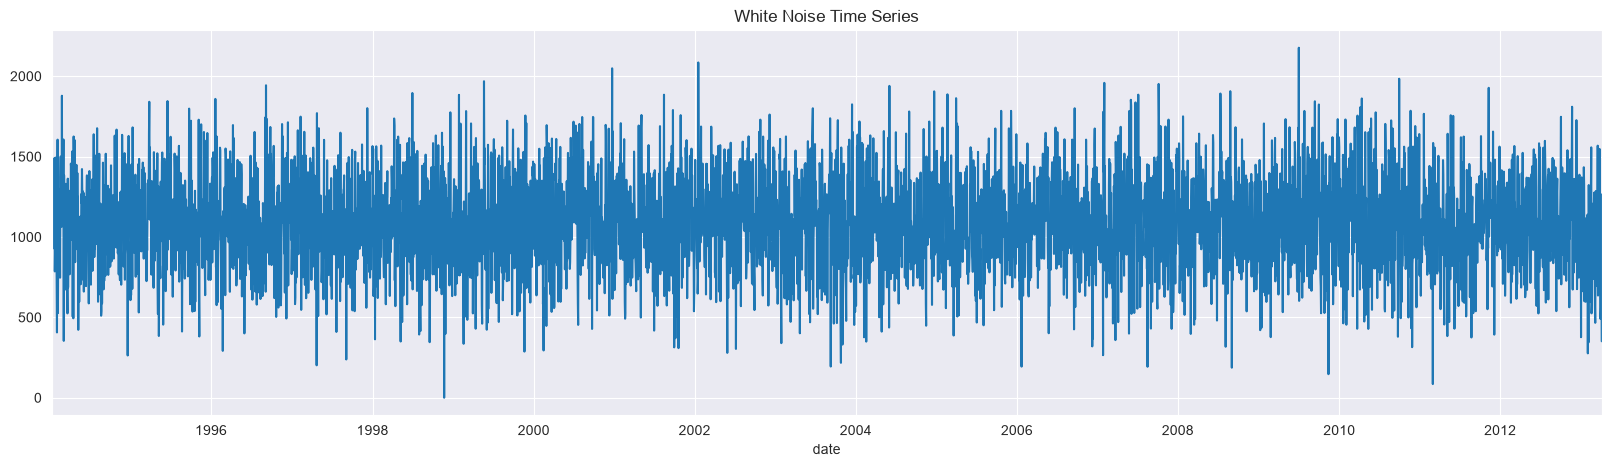

In [60]:
df.wn.plot(figsize=(20,5))
plt.title("White Noise Time Series")
plt.show()

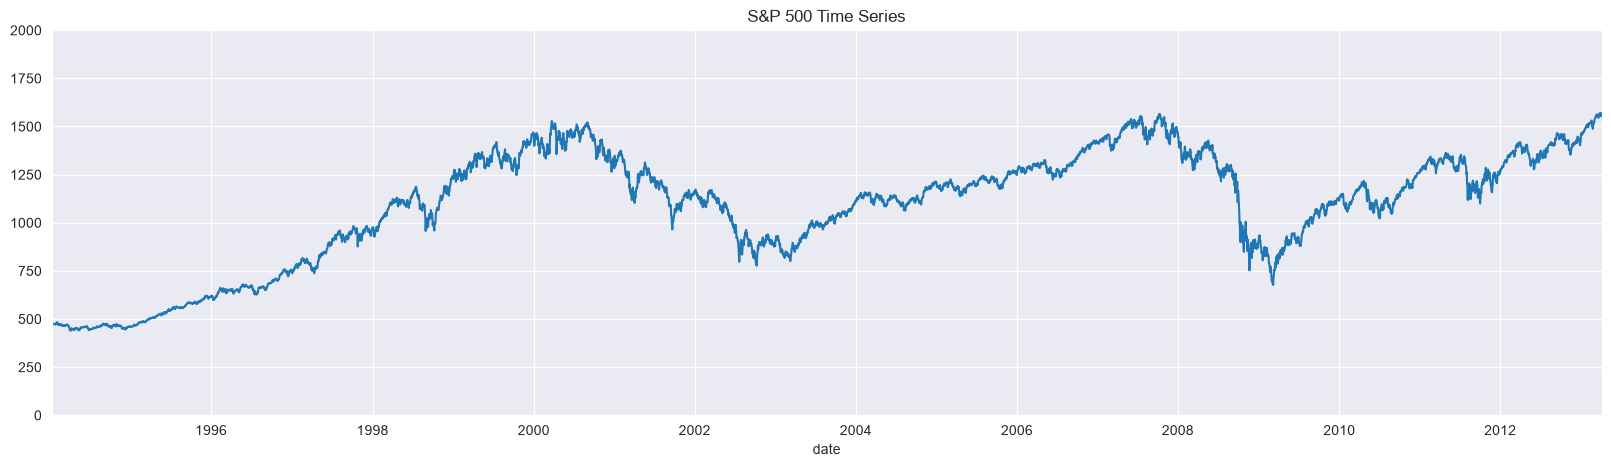

In [61]:
df.market_value.plot(figsize=(20,5))
plt.title("S&P 500 Time Series")
plt.ylim(0, 2000)
plt.show()

## Stationarity

In [68]:
adf_result = sts.adfuller(df.market_value)

print('ADF Statistic: %f' % adf_result[0])
print('p-value: %f' % adf_result[1])
print('ADF Result:', adf_result)

ADF Statistic: -1.736985
p-value: 0.412165
ADF Result: (-1.7369847452352436, 0.4121645696770623, 18, 5002, {'1%': np.float64(-3.431658008603046), '5%': np.float64(-2.862117998412982), '10%': np.float64(-2.567077669247375)}, np.float64(39904.880607487445))


/var/folders/2y/rw1f6sdn1_z84ny_s3mlv_1w0000gn/T/ipykernel_14489/273709560.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = sts.adfuller(df.market_value)


In [67]:
adf_result = sts.adfuller(df.wn)

print('ADF Statistic: %f' % adf_result[0])
print('p-value: %f' % adf_result[1])
print('ADF Result:', adf_result)


ADF Statistic: -71.150975
p-value: 0.000000
ADF Result: (-71.1509750313614, 0.0, 0, 5020, {'1%': np.float64(-3.431653316130827), '5%': np.float64(-2.8621159253018247), '10%': np.float64(-2.5670765656497516)}, np.float64(70825.27219114761))


/var/folders/2y/rw1f6sdn1_z84ny_s3mlv_1w0000gn/T/ipykernel_14489/15861525.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = sts.adfuller(df.wn)


## Seasonality

In [69]:
from statsmodels.tsa.seasonal import seasonal_decompose

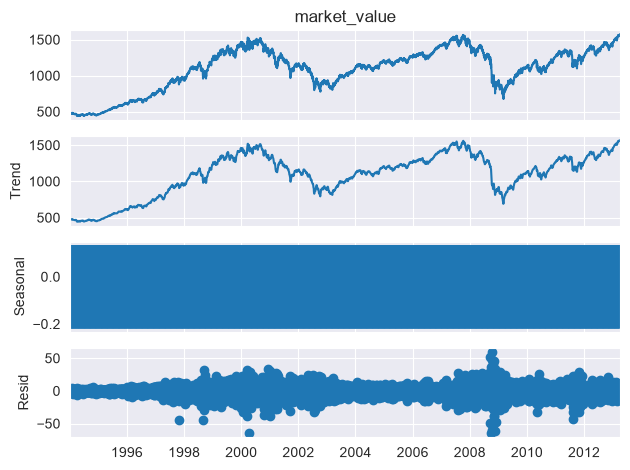

In [72]:
s_dec_additive = seasonal_decompose(df.market_value, model='additive')
s_dec_additive.plot()
plt.show()